# 0. 기본 세팅

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, ttest_rel
import statsmodels.api as sm
import os
import re

# 폰트 및 크기 설정
BIG_SIZE = 24
MEDIUM_SIZE = 20
SMALL_SIZE = 16

plt.rcdefaults()
plt.style.use('default')        # 흰색 배경
plt.rc('font', family='Times New Roman')
plt.rc('axes', titlesize=BIG_SIZE, labelsize=BIG_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=MEDIUM_SIZE)

def calculate_PIR(_df):
    if 'RUBI_best' in _df.columns:
        _df['PIR_RUBI_base'] = (_df['baseline'] - _df['RUBI_best']) / _df['baseline']
        _df['PIR_RUBI_rand'] = (_df['RANDOM_best'] - _df['RUBI_best']) / _df['RANDOM_best']
    if 'MoRUBI_best' in _df.columns:
        _df['PIR_MoRUBI_base'] = (_df['baseline'] - _df['MoRUBI_best']) / _df['baseline']
        _df['PIR_MoRUBI_rand'] = (_df['RANDOM_best'] - _df['MoRUBI_best']) / _df['RANDOM_best']
    if 'SPT_best' in _df.columns:
        _df['PIR_SPT_base'] = (_df['baseline'] - _df['SPT_best']) / _df['baseline']
        _df['PIR_SPT_rand'] = (_df['RANDOM_best'] - _df['SPT_best']) / _df['RANDOM_best']
    if 'LPT_best' in _df.columns:
        _df['PIR_LPT_base'] = (_df['baseline'] - _df['LPT_best']) / _df['baseline']
        _df['PIR_LPT_rand'] = (_df['RANDOM_best'] - _df['LPT_best']) / _df['RANDOM_best']
    if 'GT_best' in _df.columns:
        _df['PIR_GT_base'] = (_df['baseline'] - _df['GT_best']) / _df['baseline']
        _df['PIR_GT_rand'] = (_df['RANDOM_best'] - _df['GT_best']) / _df['RANDOM_best']
    _df['PIR_RAND_base'] = (_df['baseline'] - _df['RANDOM_best']) / _df['baseline']
    return _df

def statistical_correlation(_df, _x_target, _y_target):
    corr, p_value = pearsonr(_df[_x_target], _df[_y_target])
    print(f"피어슨 상관계수 (r): {corr:.4f}")
    print(f"p-value: {p_value:.6f}")
    # 유의수준 판단
    alpha = 0.05
    if p_value < alpha:
        print(f"=> 귀무가설 기각: {_x_target} 과 {_y_target} 사이에 통계적으로 유의한 상관관계가 있음.")
    else:
        print(f"=> 귀무가설 채택: {_x_target} 과 {_y_target} 사이에 상관관계가 통계적으로 유의하지 않음.")
        
def statistical_ttest(_df, _x_target, _y_target):
    # 두 집단의 차이 계산
    t_stat, p_two_tailed = ttest_rel(df[_x_target], df[_y_target])
    # 단측 검정용 p-value (RUBI < GT)
    if t_stat < 0:
        p_one_tailed = p_two_tailed / 2
    else:
        p_one_tailed = 1 - p_two_tailed / 2
    print(f"t-statistic: {t_stat:.4f}")
    print(f"One-tailed p-value: {p_one_tailed:.6f}")
    alpha = 0.05
    if p_one_tailed < alpha:
        print(f"=> 귀무가설 기각: {_x_target} 이 {_y_target} 보다 유의하게 작음.")
    else:
        print(f"=> 귀무가설 채택: {_x_target} 이 {_y_target} 보다 작다고 보기 어려움.")

def comparison_plot(_df, _x, _y1, _y2):
    label_mapping = {'num_job':'Number of Jobs',
                     'num_machine':'Number of Machines',
                     'PIR_RUBI_base':'RUBI',
                     'PIR_RAND_base':'Random',
                     }
    color_mapping = {'PIR_RUBI_base':'red',
                     'PIR_RAND_base':'blue',
                     }
    marker_mapping = {'PIR_RAND_base':'o',
                      'PIR_RUBI_base':'*',}
    plt.figure(figsize=(8, 6))
    
    plt.plot(
            _df[_x],
            _df[_y1],
            c=color_mapping[_y1],
            marker=marker_mapping[_y1],
            label=label_mapping[_y1],
        )   
    plt.plot(
            _df[_x],
            _df[_y2],
            c=color_mapping[_y2],
            marker=marker_mapping[_y2],
            label=label_mapping[_y2],
        ) 
    plt.xlabel(label_mapping[_x], fontsize=20, fontname='Times New Roman')
    plt.xticks([i*5 for i in range(1,11)])
    plt.ylabel('PIR(Relative to Baseline)', fontsize=16, fontname='Times New Roman')
    # plt.title('RUBI_best vs I_f', fontsize=20, fontname='Times New Roman')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(
        prop={'family': 'Times New Roman', 'size': 14}
    )
    
    plt.tight_layout()
    plt.savefig(f'Initialization_{_x}.png', dpi=300)


# 1. Initialization_$\sigma_{pt}$

In [26]:
df = pd.read_csv('Initialization_comparison_20251127121858.csv')
df = calculate_PIR(df)
# 동일한 (num_job, num_machine, mean, std) 조합별로 PIR_* 값 평균 계산
group_cols = ['num_job', 'num_machine', 'mean', 'std']
# PIR_* 컬럼 자동 탐색
pir_cols = [c for c in df.columns if c.startswith('PIR_')]
# 그룹별 평균 계산
df_mean = df.groupby(group_cols)[pir_cols].mean().reset_index()
# 결과 확인
df_mean

,num_job,num_machine,mean,std,PIR_RUBI_base,PIR_RUBI_rand,PIR_MoRUBI_base,PIR_MoRUBI_rand,PIR_SPT_base,PIR_SPT_rand,PIR_LPT_base,PIR_LPT_rand,PIR_GT_base,PIR_GT_rand,PIR_RAND_base
0,10,10,30,1,0.355972,0.188045,0.355708,0.187682,0.382913,0.221811,0.372782,0.208825,0.326322,0.150623,0.206075
1,10,10,30,2,0.352895,0.185384,0.354985,0.188022,0.358198,0.192317,0.366570,0.202641,0.314752,0.137217,0.205142
2,10,10,30,3,0.351576,0.183195,0.355704,0.188443,0.307689,0.128686,0.350733,0.182432,0.316806,0.139198,0.205799
3,10,10,30,4,0.350773,0.182702,0.355760,0.188987,0.328253,0.155018,0.322266,0.146937,0.325618,0.150652,0.205376
4,10,10,30,5,0.351992,0.183244,0.354413,0.186188,0.315434,0.137028,0.320784,0.143941,0.317469,0.139560,0.206464
5,10,10,30,6,0.350835,0.180226,0.356792,0.187598,0.294418,0.108971,0.309197,0.127663,0.316985,0.137184,0.207952
6,10,10,30,7,0.350964,0.178359,0.349259,0.176185,0.306743,0.122449,0.316730,0.134954,0.310588,0.127231,0.209860
7,10,10,30,8,0.350174,0.174831,0.348708,0.173034,0.303839,0.116527,0.310513,0.124461,0.308214,0.121354,0.212273
8,10,10,30,9,0.348266,0.169829,0.346739,0.167954,0.315467,0.128390,0.304741,0.114487,0.315951,0.128606,0.214662
9,10,10,30,10,0.346842,0.166323,0.347429,0.167176,0.310948,0.120777,0.294821,0.100032,0.312907,0.123486,0.216097


## 1.1. 상관관계 검정 - $\sigma_{pt}$

In [27]:
from scipy.stats import pearsonr
x_target = 'std'
y_target = 'PIR_RUBI_base'
# I_b 과 PIR_RUBI_rand 간 Quadr상관관계 검정
corr, p_value = pearsonr(df[x_target], df[y_target])

print(f"피어슨 상관계수 (r): {corr:.4f}")
print(f"p-value: {p_value:.6f}")

# 유의수준 판단
alpha = 0.05
if p_value < alpha:
    print(f"=> 귀무가설 기각: {x_target} 과 {y_target} 사이에 통계적으로 유의한 상관관계가 있음.")
else:
    print(f"=> 귀무가설 채택: {x_target} 과 {y_target} 사이에 상관관계가 통계적으로 유의하지 않음.")

df = pd.read_csv('Initialization_comparison_20251128161538.csv')
df = calculate_PIR(df)

x_target = 'I_b'
y_target = 'PIR_RUBI_rand'

# 1️⃣ 변수 생성
x = df[x_target]
x2 = x ** 2
y = df[y_target]

# 2️⃣ 회귀모형 적합: y = β0 + β1*x + β2*x²
X = pd.DataFrame({'x': x, 'x2': x2})
X = sm.add_constant(X)  # β0 (상수항)
model = sm.OLS(y, X).fit()

# 3️⃣ 결과 출력
print(model.summary())

# 4️⃣ 해석: x²항의 계수 유의성 확인
beta2_p = model.pvalues['x2']
beta2_coef = model.params['x2']

alpha = 0.05
print(f"\nQuadratic term coefficient (β₂): {beta2_coef:.4f}")
print(f"p-value for β₂: {beta2_p:.6f}")

if beta2_p < alpha:
    print(f"=> 귀무가설 기각: {x_target}² 항이 유의함 → Quadratic 관계 존재")
else:
    print(f"=> 귀무가설 채택: {x_target}² 항이 유의하지 않음 → Quadratic 관계 없음")


피어슨 상관계수 (r): -0.2723
p-value: 0.000144
=> 귀무가설 기각: std 과 PIR_RUBI_base 사이에 통계적으로 유의한 상관관계가 있음.
                            OLS Regression Results                            
Dep. Variable:          PIR_RUBI_rand   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.503
Method:                 Least Squares   F-statistic:                     101.6
Date:                Thu, 11 Dec 2025   Prob (F-statistic):           4.77e-31
Time:                        13:28:08   Log-Likelihood:                 326.85
No. Observations:                 200   AIC:                            -647.7
Df Residuals:                     197   BIC:                            -637.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

## 1.2. Plotting

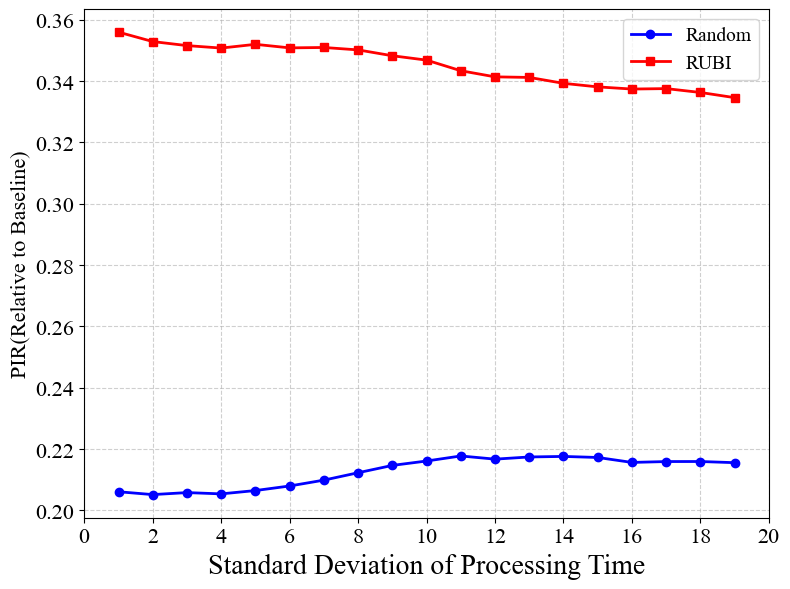

In [28]:
# 1) base 계열만 추출
pir_base_cols = ['PIR_RAND_base','PIR_RUBI_base']
markers = ['o', 's', '^', '*', 'v']  # 원, 사각형, 다이아, 삼각형(위), 삼각형(아래)
colors = ['blue', 'red', 'green']
label_mapping = {'RAND':'Random', 'RUBI':'RUBI'}

plt.figure(figsize=(8, 6))
# 2) 각 PIR_*_base 컬럼별로 num_machine 에 따른 변화 그리기
for i, col in enumerate(pir_base_cols):
    plt.plot(
        df_mean['std'],
        df_mean[col],
        marker=markers[i % len(markers)],
        label=label_mapping[col.replace('PIR_', '').replace('_base', '')],
        color=colors[i % len(markers)],
        linewidth=2
    )

# 3) 축, 제목, 범례 설정
plt.xlabel('Standard Deviation of Processing Time', fontsize=20, fontname='Times New Roman')
plt.xticks([i for i in range(0,21,2)])
plt.ylabel('PIR(Relative to Baseline)', fontsize=16, fontname='Times New Roman')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(
    prop={'family': 'Times New Roman', 'size': 14}
)
plt.tight_layout()
plt.savefig('Initialization_Std.png', dpi=300)

# 2. Initialization: $N_{\textrm{job}}$ & $N_{\textrm{machine}}$

In [45]:
df_job = pd.read_csv('Initialization_comparison_20251127153750.csv')
df_job = calculate_PIR(df_job)

df_machine = pd.read_csv('Initialization_comparison_20251127140025.csv')
df_machine = calculate_PIR(df_machine)

statistical_correlation(df_job, 'num_job','PIR_RUBI_rand')
statistical_correlation(df_machine, 'num_machine','PIR_RUBI_rand')

statistical_correlation(df_job, 'num_job','PIR_RUBI_rand')
statistical_correlation(df_machine, 'num_machine','PIR_RUBI_rand')

피어슨 상관계수 (r): 0.1005
p-value: 0.345721
=> 귀무가설 채택: num_job 과 PIR_RUBI_rand 사이에 상관관계가 통계적으로 유의하지 않음.
피어슨 상관계수 (r): 0.1700
p-value: 0.109087
=> 귀무가설 채택: num_machine 과 PIR_RUBI_rand 사이에 상관관계가 통계적으로 유의하지 않음.
피어슨 상관계수 (r): 0.1005
p-value: 0.345721
=> 귀무가설 채택: num_job 과 PIR_RUBI_rand 사이에 상관관계가 통계적으로 유의하지 않음.
피어슨 상관계수 (r): 0.1700
p-value: 0.109087
=> 귀무가설 채택: num_machine 과 PIR_RUBI_rand 사이에 상관관계가 통계적으로 유의하지 않음.


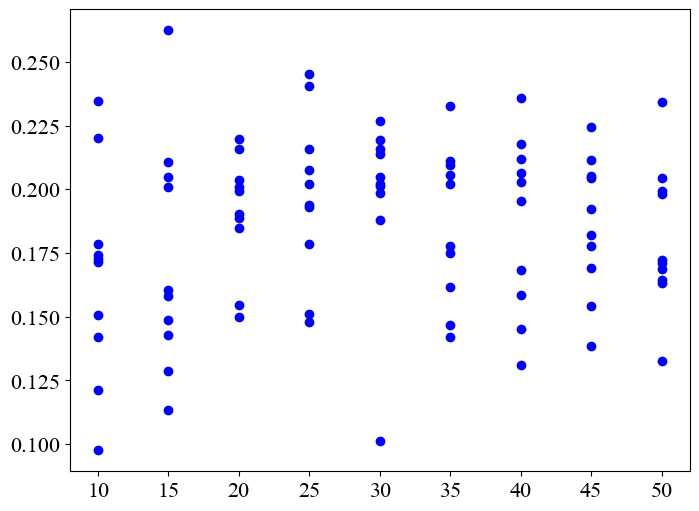

In [47]:
plt.figure(figsize=(8, 6))
plt.scatter(df_job['num_job'], df_job['PIR_RUBI_rand'], marker='o', color='blue')
# plt.scatter(df_machine['num_machine'], df_job['PIR_RUBI_rand'], marker='o', color='blue')
plt.show()

In [58]:
df = pd.read_csv('../Initialization_comparison_20251204142410.csv')
df = calculate_PIR(df)

# 평균낼 target column 지정
target_cols = [
    'PIR_RUBI_base', 'PIR_RUBI_rand',
    'PIR_GT_base', 'PIR_GT_rand', 'PIR_RAND_base'
]

# num_job, num_machine 별로 seed 평균 계산
df_mean_by_seed = (
    df.groupby(['num_job', 'num_machine'])[target_cols]
    .mean()
    .reset_index()
    .sort_values(['num_job', 'num_machine'])
)
df_mean_by_seed_machine = (
    df.groupby(['num_job'])[target_cols]
    .mean()
    .reset_index()
    .sort_values(['num_job'])
)
df_mean_by_seed_job = (
    df.groupby(['num_machine'])[target_cols]
    .mean()
    .reset_index()
    .sort_values(['num_machine'])
)

In [68]:
statistical_correlation(df_mean_by_seed_machine, 'num_job','PIR_RUBI_base')

피어슨 상관계수 (r): 0.5870
p-value: 0.074446
=> 귀무가설 채택: num_job 과 PIR_RUBI_base 사이에 상관관계가 통계적으로 유의하지 않음.


피어슨 상관계수 (r): 0.5870
p-value: 0.074446
=> 귀무가설 채택: num_job 과 PIR_RUBI_base 사이에 상관관계가 통계적으로 유의하지 않음.


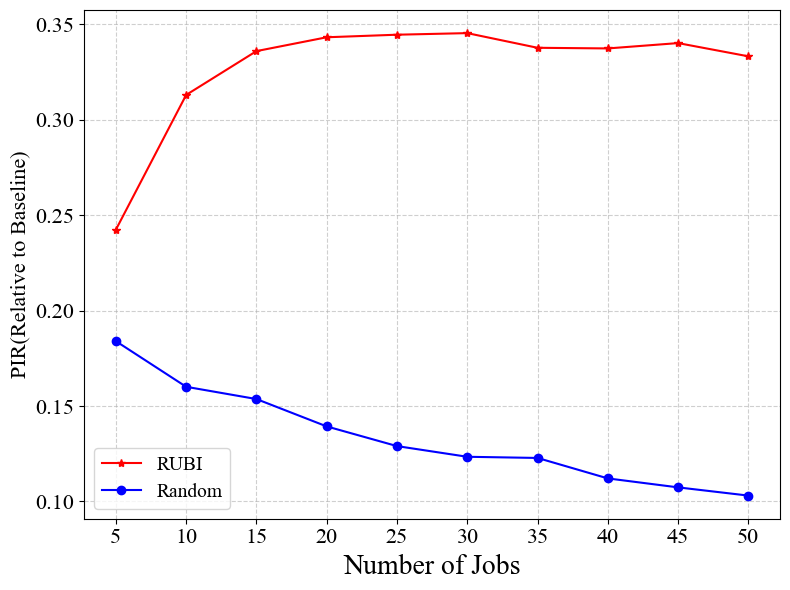

In [64]:
statistical_correlation(df_mean_by_seed_machine, 'num_job','PIR_RUBI_base')
comparison_plot(df_mean_by_seed_machine, 'num_job', 'PIR_RUBI_base', 'PIR_RAND_base')

피어슨 상관계수 (r): 0.6892
p-value: 0.027487
=> 귀무가설 기각: num_machine 과 PIR_RUBI_base 사이에 통계적으로 유의한 상관관계가 있음.


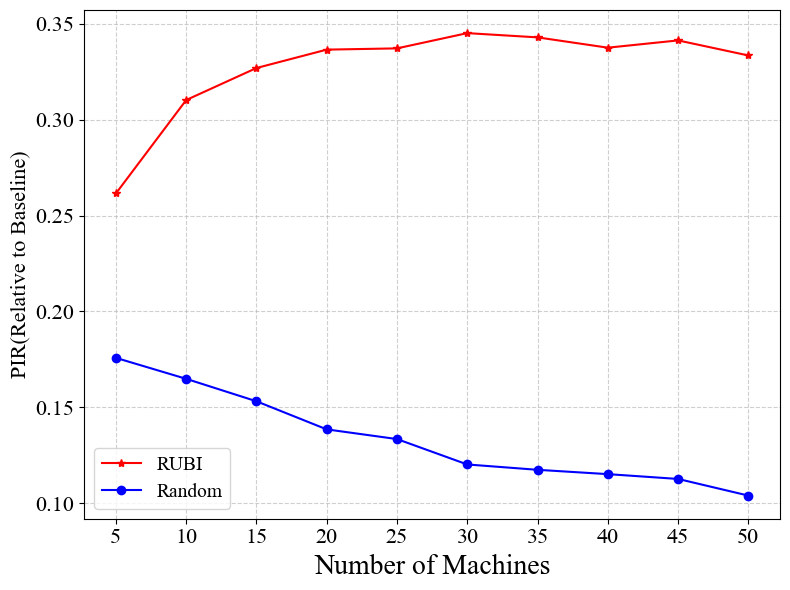

In [63]:
statistical_correlation(df_mean_by_seed_job, 'num_machine','PIR_RUBI_base')
comparison_plot(df_mean_by_seed_job, 'num_machine', 'PIR_RUBI_base', 'PIR_RAND_base')

# 3. $I_b$, $I_f$ 에 따른 변화 관찰

In [50]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# CSV 읽기
df = pd.read_csv('Initialization_comparison_20251204111842.csv')
df = calculate_PIR(df)

In [55]:
import pandas as pd

_df = pd.read_csv('../Initialization_comparison_20251204142410.csv')
_df = calculate_PIR(_df)

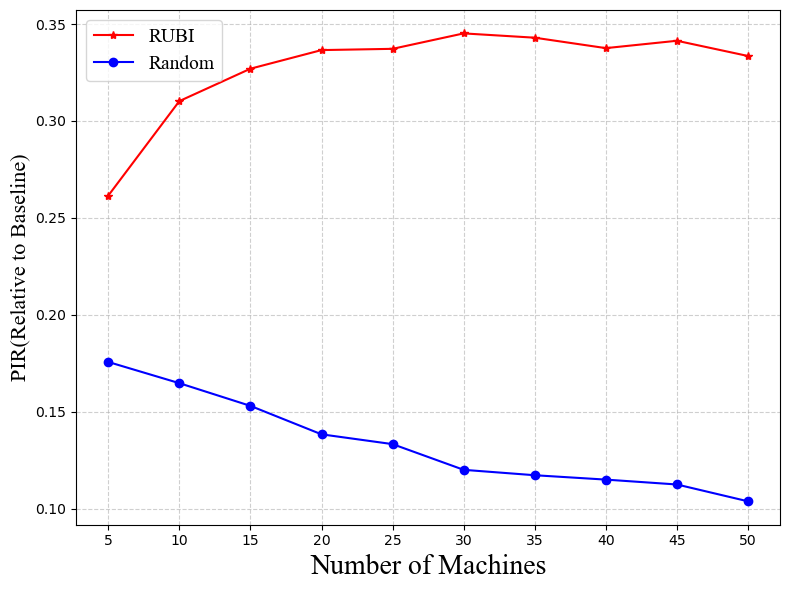

In [40]:
# df = calculate_PIR(df)
_df = df_mean_by_seed_job
plt.figure(figsize=(8, 6))
color = ['red', 'orange', 'yellow', 'green', 'blue', 'violet', 'purple']
markers = ['o', 's', '^', '*', 'v']  # 원, 사각형, 다이아, 삼각형(위), 삼각형(아래)

plt.plot(
        _df['num_machine'],
        _df['PIR_RUBI_base'],
        c='red',
        marker='*',
        label='RUBI'
    )   
plt.plot(
        _df['num_machine'],
        _df['PIR_RAND_base'],
        c='blue',
        marker='o',
        label='Random'
    ) 
plt.xlabel('Number of Machines', fontsize=20, fontname='Times New Roman')
plt.xticks([i*5 for i in range(1,11)])
plt.ylabel('PIR(Relative to Baseline)', fontsize=16, fontname='Times New Roman')
# plt.title('RUBI_best vs I_f', fontsize=20, fontname='Times New Roman')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(
    prop={'family': 'Times New Roman', 'size': 14}
)

plt.tight_layout()
plt.savefig('Initialization_n_machine.png', dpi=300)
# plt.show()

In [42]:

x_target = 'num_job'
y_target = 'PIR_RUBI_base'
# I_b 과 PIR_RUBI_rand 간 Quadr상관관계 검정
corr, p_value = pearsonr(df_mean_by_seed_machine[x_target], df_mean_by_seed_machine[y_target])

print(f"피어슨 상관계수 (r): {corr:.4f}")
print(f"p-value: {p_value:.6f}")

# 유의수준 판단
alpha = 0.05
if p_value < alpha:
    print(f"=> 귀무가설 기각: {x_target} 과 {y_target} 사이에 통계적으로 유의한 상관관계가 있음.")
else:
    print(f"=> 귀무가설 채택: {x_target} 과 {y_target} 사이에 상관관계가 통계적으로 유의하지 않음.")


피어슨 상관계수 (r): 0.5870
p-value: 0.074446
=> 귀무가설 채택: num_job 과 PIR_RUBI_base 사이에 상관관계가 통계적으로 유의하지 않음.


In [43]:

x_target = 'num_machine'
y_target = 'PIR_RUBI_base'
# I_b 과 PIR_RUBI_rand 간 Quadr상관관계 검정
corr, p_value = pearsonr(df_mean_by_seed_job[x_target], df_mean_by_seed_job[y_target])

print(f"피어슨 상관계수 (r): {corr:.4f}")
print(f"p-value: {p_value:.6f}")

# 유의수준 판단
alpha = 0.05
if p_value < alpha:
    print(f"=> 귀무가설 기각: {x_target} 과 {y_target} 사이에 통계적으로 유의한 상관관계가 있음.")
else:
    print(f"=> 귀무가설 채택: {x_target} 과 {y_target} 사이에 상관관계가 통계적으로 유의하지 않음.")


피어슨 상관계수 (r): 0.6892
p-value: 0.027487
=> 귀무가설 기각: num_machine 과 PIR_RUBI_base 사이에 통계적으로 유의한 상관관계가 있음.


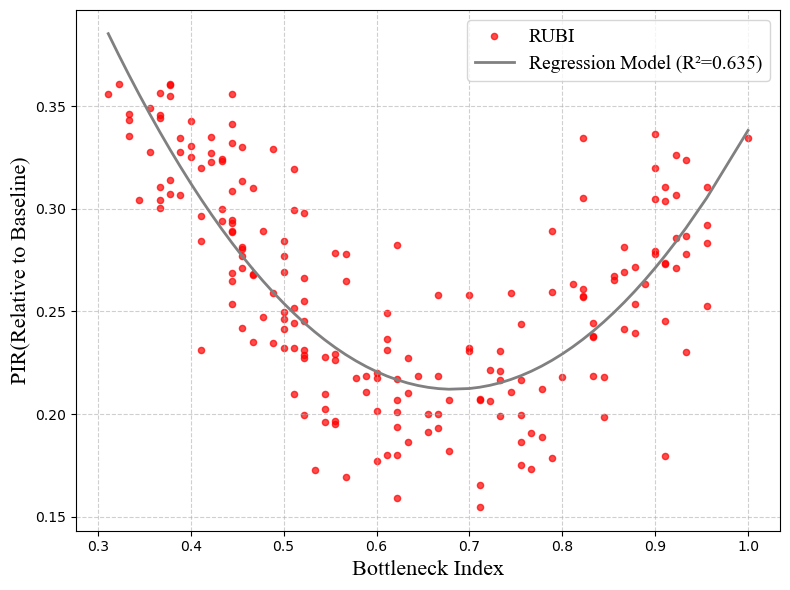

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = pd.read_csv('Initialization_comparison_20251128161538.csv')
df = calculate_PIR(df)

# 독립/종속 변수
X = df['I_b'].values.reshape(-1, 1)
y = df['PIR_RUBI_base'].values

# 2차항 피팅
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)
y_pred = model.predict(X_poly)
r2 = r2_score(y, y_pred)

# 시각화를 위한 정렬
sort_idx = np.argsort(X.flatten())
X_sorted = X.flatten()[sort_idx]
y_pred_sorted = y_pred[sort_idx]

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X, y, c='red', alpha=0.7, s=20, label='RUBI')
plt.plot(X_sorted, y_pred_sorted, color='grey', linewidth=2, label=f'Regression Model (R²={r2:.3f})')
plt.xlabel('Bottleneck Index', fontsize=16, fontname='Times New Roman')
plt.ylabel('PIR(Relative to Baseline)', fontsize=16, fontname='Times New Roman')
# plt.title('Quadratic Relationship: I_b vs PIR_RUBI_base', fontsize=20, fontname='Times New Roman')
plt.legend(
    prop={'family': 'Times New Roman', 'size': 14})
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('Initialization_Ib.png', dpi=300)
# plt.show()


# 4. 시간 비교

In [2]:
df = pd.read_csv('Initialization_comparison_20251204111842.csv')
statistical_ttest(df, 'RANDOM_time', 'RUBI_time')
statistical_ttest(df, 'RUBI_time', 'GT_time')

t-statistic: -12.9223
One-tailed p-value: 0.000000
=> 귀무가설 기각: RANDOM_time 이 RUBI_time 보다 유의하게 작음.
t-statistic: -10.1454
One-tailed p-value: 0.000000
=> 귀무가설 기각: RUBI_time 이 GT_time 보다 유의하게 작음.


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_113604\1893298606.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_target['Instance_Num'] = df_target['Filename'].str.extract(r'la(\d+)').astype(int)


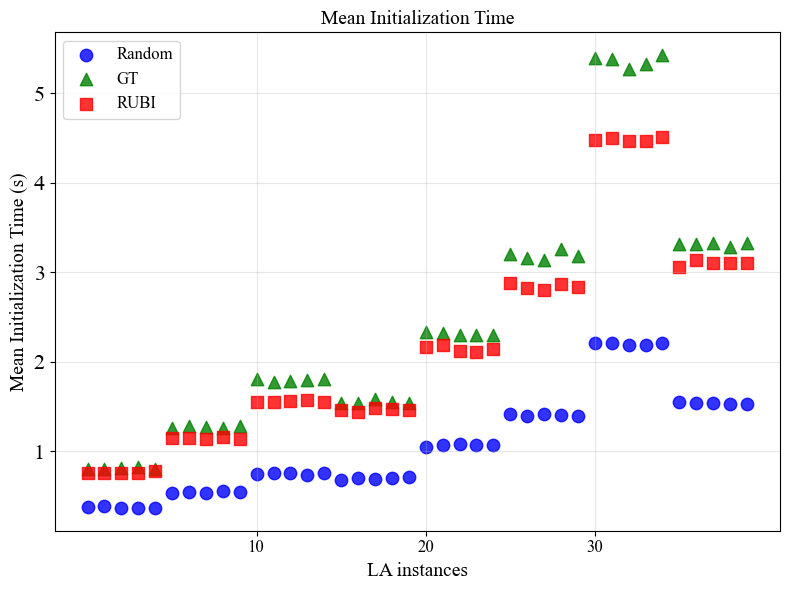

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 불러오기
df = pd.read_csv('../result/result_total.csv')

# la01 ~ la40 인스턴스 선택
target_instances = [f'la{str(i).zfill(2)}' for i in range(1, 41)]
df_target = df[df['Filename'].isin(target_instances)]

# instance 번호(정수) 추출 column 추가
df_target['Instance_Num'] = df_target['Filename'].str.extract(r'la(\d+)').astype(int)

# ────────────────────────────────
# Figure 1 : RANDOM vs RUBI — Initialization Time (mean-based scatter)
# ────────────────────────────────
df_init = df_target[df_target['Initialization'].isin(['RANDOM', 'RUBI', 'GT'])]

# instance별 mean 계산
df_init_mean = (
    df_init.groupby(['Filename', 'Initialization'])['Initialization Time']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 6))
label_mapping = {'RANDOM':'Random',
                 'RUBI':'RUBI',
                 'GT':'GT'}
for method, color, marker in zip(['RANDOM', 'GT', 'RUBI'], ['blue', 'green', 'red'], ['o', '^', 's']):
    sub = df_init_mean[df_init_mean['Initialization'] == method]
    plt.scatter(
        sub['Filename'], sub['Initialization Time'],
        label=label_mapping[method], color=color, marker=marker, s=80, alpha=0.8
    )

plt.title('Mean Initialization Time', fontsize=14, fontname='Times New Roman')
plt.xlabel('LA instances', fontsize=14, fontname='Times New Roman')
plt.ylabel('Mean Initialization Time (s)', fontsize=14, fontname='Times New Roman')
plt.xticks(ticks=[10, 20, 30], labels=['10', '20', '30'], fontsize=12, fontname='Times New Roman')
plt.legend(prop={'family': 'Times New Roman', 'size': 12}, loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Time_random_rubi_gt.svg', dpi=300)
# plt.show()


# 5. Industrial Data 비교 실험

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../Initialization_comparison_20251209195944.csv')

In [11]:
df.columns

Index(['num_job', 'num_machine', 'mean', 'std', 'seed', 'I_b', 'I_f',
       'baseline', 'RANDOM_best', 'RANDOM_time', 'RUBI_best', 'RUBI_time',
       'SPT_best', 'SPT_time', 'LPT_best', 'LPT_time', 'GT_best', 'GT_time'],
      dtype='object')

In [13]:
import pandas as pd

# df = pd.read_csv("your_file.csv")  # 이미 로드되어 있다면 생략

def summarize_by_seed_mean(df: pd.DataFrame) -> pd.DataFrame:
    # 인스턴스(조건) 식별 컬럼들: seed만 빼고 나머지 특성으로 묶기
    group_cols = ['num_job', 'num_machine']

    # 방법론별 best(=makespan) / time 컬럼 매핑
    metric_map = {
        'RANDOM': {'makespan': 'RANDOM_best', 'time': 'RANDOM_time'},
        'RUBI':   {'makespan': 'RUBI_best',   'time': 'RUBI_time'},
        'GT':     {'makespan': 'GT_best',     'time': 'GT_time'},
    }

    # group별 seed 평균을 계산해서 wide 형태로 붙이기
    parts = []
    for method, cols in metric_map.items():
        tmp = (
            df.groupby(group_cols, as_index=False)[[cols['makespan'], cols['time']]]
              .mean()
              .rename(columns={
                  cols['makespan']: f'{method}_makespan_mean',
                  cols['time']:     f'{method}_time_mean',
              })
        )
        parts.append(tmp)

    # 순차적으로 merge
    summary = parts[0]
    for tmp in parts[1:]:
        summary = summary.merge(tmp, on=group_cols, how='inner')

    # baseline도 그룹별로 동일하다고 가정하고 포함 (다르면 mean으로 요약)
    if 'baseline' in df.columns:
        base = df.groupby(group_cols, as_index=False)['baseline'].mean()
        summary = summary.merge(base, on=group_cols, how='left')

    # 보기 좋은 컬럼 순서
    ordered_cols = (
        group_cols
        + (['baseline'] if 'baseline' in summary.columns else [])
        + [
            'RANDOM_makespan_mean', 'RANDOM_time_mean',
            'RUBI_makespan_mean',   'RUBI_time_mean',
            'GT_makespan_mean',     'GT_time_mean',
        ]
    )
    summary = summary[ordered_cols].sort_values(group_cols).reset_index(drop=True)
    return summary


# 사용 예시
df_summary = summarize_by_seed_mean(df)
print(df_summary)
df_summary.to_csv("summary_by_seed_mean_quay.csv", index=False)


   num_job  num_machine     baseline  RANDOM_makespan_mean  RANDOM_time_mean  \
0      200            5  49131.02015             45397.155         20.177055   

   RUBI_makespan_mean  RUBI_time_mean  GT_makespan_mean  GT_time_mean  
0            41815.08        35.94172          41715.29     60.337014  


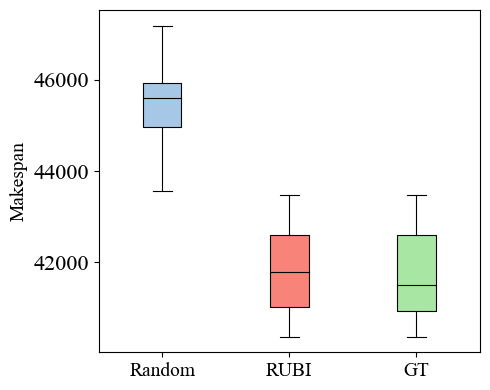

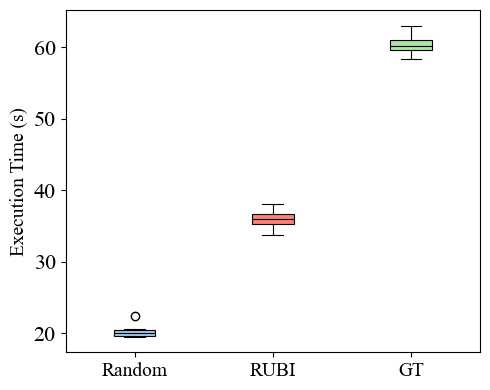

In [14]:

plt.rc('font', family='Times New Roman')
# -----------------------------
# Figure 1: Makespan boxplot
# -----------------------------
fig1, ax1 = plt.subplots(figsize=(5, 4))
boxes1 = ax1.boxplot(
    [df['RANDOM_best'], df['RUBI_best'], df['GT_best']],
    labels=['Random', 'RUBI', 'GT'],
    patch_artist=True
)

# Patch color 설정
colors1 = ['#A7C7E7', '#F88379', '#A8E6A3']  # pastel skyblue, coral red, green
for patch, color in zip(boxes1['boxes'], colors1):
    patch.set(facecolor=color, edgecolor='black', linewidth=0.8)
for element in ['whiskers', 'caps', 'medians']:
    plt.setp(boxes1[element], color='black', linewidth=0.8)

ax1.set_ylabel('Makespan', fontsize=14, fontname='Times New Roman')
ax1.tick_params(axis='x', labelsize=14)
fig1.tight_layout()
fig1.savefig('Figure1_Makespan_boxplot_Quay.svg', dpi=300)


# -----------------------------
# Figure 2: Time boxplot
# -----------------------------
fig2, ax2 = plt.subplots(figsize=(5, 4))
boxes2 = ax2.boxplot(
    [df['RANDOM_time'], df['RUBI_time'], df['GT_time']],
    labels=['Random', 'RUBI', 'GT'],
    patch_artist=True
)

# Patch color 설정
colors2 = ['#A7C7E7', '#F88379', '#A8E6A3']
for patch, color in zip(boxes2['boxes'], colors2):
    patch.set(facecolor=color, edgecolor='black', linewidth=0.8)
for element in ['whiskers', 'caps', 'medians']:
    plt.setp(boxes2[element], color='black', linewidth=0.8)

ax2.set_ylabel('Execution Time (s)', fontsize=14, fontname='Times New Roman')
ax2.tick_params(axis='x', labelsize=14)
fig2.tight_layout()
fig2.savefig('Figure2_Time_boxplot_Quay.svg', dpi=300)